## Project 1: AI-Driven Citizen Grievance & Sentiment Analysis
## Week 1 — Data Cleaning, Text Preprocessing & EDA


## Step 1: Install & Import Libraries

In [3]:
# Run this cell once to install required libraries
!pip install nltk spacy wordcloud matplotlib seaborn pandas scikit-learn
!python -m spacy download en_core_web_sm

   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
    --------------------------------------- 0.3/14.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.2 MB 1.3 MB/s eta 0:00:11
   -- ------------------------------------- 0.8/14.2 MB 1.3 MB/s eta 0:00:11
   -- ------------------------------------- 1.0/14.2 MB 1.3 MB/s eta 0:00:11
   --- ------------------------------------ 1.3/14.2 MB 1.3 MB/s eta 0:00:10
   ---- ----------------------------------- 1.6/14.2 MB 1.3 MB/s eta 0:00:10
   ----- ---------------------------------- 1.8/14.2 MB 1.3 MB/s eta 0:00:10
   ----- ---------------------------------- 2.1/14.2 MB 1.3 MB/s eta 0:00:10
   ------ --------------------------------- 2.4/14.2 MB 1.3 MB/s eta 0:00:10
   ------- -------------------------------- 2.6/14.2 MB 1.3 MB/s eta 0:00:09
   -------- ------------------------------- 3.1/14.2 MB 1.3 MB/s eta 0:00:09
   --------- ------------------------------ 3.4/14.2 MB 1.3 MB/s eta 0:00:09
   ----------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import re
import string
import nltk
import spacy

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print(' All libraries loaded successfully!')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HCORP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HCORP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HCORP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


✅ All libraries loaded successfully!


---
## Step 2: Load Dataset

> **Note:** Download the NYC 311 dataset from Kaggle and upload it to Colab, OR use the synthetic data generator below.

In [19]:
df = pd.read_csv('complaints_processed.csv')
print(f' Data loaded successfully! Shape: {df.shape}')

 Data loaded successfully! Shape: (162421, 3)


---
## Step 3: Exploratory Data Analysis (EDA)

In [20]:
# Basic info
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicate Rows ===')
print(df.duplicated().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  162421 non-null  int64 
 1   product     162421 non-null  object
 2   narrative   162411 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.7+ MB
None

=== Missing Values ===
Unnamed: 0     0
product        0
narrative     10
dtype: int64

=== Duplicate Rows ===
0


In [23]:
df['product'].value_counts()

product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64

In [ ]:
# Fill categorical/text columns 
df['narrative'] = df['narrative'].fillna(df['narrative'].mode()[0])

# Verify no missing values remain
print("\nMissing values after filling:")
print(df.isnull().sum())


Missing values after filling:
Unnamed: 0    0
product       0
narrative     0
dtype: int64


=== Text Length Stats ===
         text_length     word_count
count  162421.000000  162421.000000
mean      588.515180      80.229890
std       830.956002     108.869492
min         3.000000       1.000000
25%       192.000000      27.000000
50%       361.000000      50.000000
75%       683.000000      95.000000
max     20596.000000    2685.000000


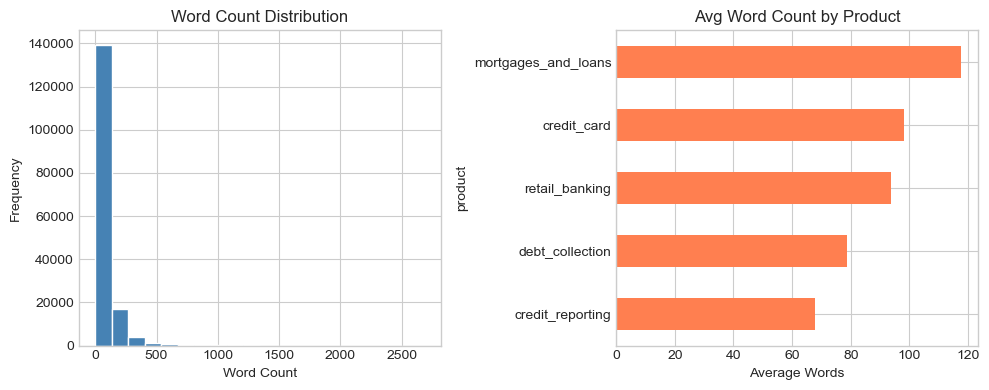

In [22]:
# Complaint text length analysis

df['text_length'] = df['narrative'].fillna('').apply(len)
df['word_count'] = df['narrative'].fillna('').apply(lambda x: len(x.split()))

print('=== Text Length Stats ===')
print(df[['text_length', 'word_count']].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['word_count'], bins=20, color='steelblue', edgecolor='white')
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.groupby('product')['word_count'].mean().sort_values().plot(kind='barh', color='coral')
plt.title('Avg Word Count by Product')
plt.xlabel('Average Words')

plt.tight_layout()
plt.savefig('eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()
